# Estimation of green and brown occupational shares based on ESCO
Felix Zaussinger | 27.04.2022

## Core Analysis Goal(s)
1. Estimate green and brown occupational shares based on different approaches
    - relationship type: essential + optional, essential only, weights by e/o
    -
2. Validate skill classifications: ESCO vs. ETH
3. Check if there is a meaningful threshold for classifying green/brown occupations

## Key Insight(s)
1.
2.
3.

In [1]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils

# import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("poster")
sns.set(rc={"figure.figsize": (16, 9.0)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths(fn_config_path="paths_config.yml")

Source module imports

In [2]:
from src import utils, stats_utils, plotting_utils
from src.data.framework import Esco

Code ...

In [3]:
of = Esco()

In [4]:
smd = of.combine_skills_metadata()

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)
C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\openpyxl\worksheet\_reader.py:312: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


In [5]:
of.skills_metadata

,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description,scope_eth,skill_green_esco,machineScore_green,skill_green_eth,broaderConceptPT,alternative_class_eth,comment_eth,broaderConceptUri,impact_eth,scope_eth_brown,machineScore_brown,skill_brown_eth,alternative_class_eth_brown,impact_eth_brown,comment_eth_brown,skill_brown_esco,skill_neutral_esco,skill_classification_esco,coreness
0,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0005c151-5b5a...,skill/competence,sector-specific,manage musical staff,manage staff of music\ncoordinate duties of mu...,NaN,released,2016-12-20T17:43:43Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Assign and manage staff tasks in areas such as...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.002187
1,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00064735-8fad...,skill/competence,occupation-specific,supervise correctional procedures,oversee prison procedures\nmanage correctional...,NaN,released,2016-12-20T20:17:49Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Supervise the operations of a correctional fac...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.000000
2,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/000709ed-2be5...,skill/competence,sector-specific,apply anti-oppressive practices,apply non-oppressive practices\napply an anti-...,NaN,released,2016-12-20T19:18:19Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,"Identify oppression in societies, economies, c...",NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.000748
3,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0007bdc2-dd15...,skill/competence,sector-specific,control compliance of railway vehicles regulat...,monitoring of compliance with railway vehicles...,NaN,released,2016-12-20T20:02:19Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,"Inspect rolling stock, components and systems ...",NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.049473
4,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00090cc1-1f27...,skill/competence,cross-sector,identify available services,establish available services\ndetermine rehabi...,NaN,released,2016-12-20T20:15:17Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Identify the different services available for ...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.001577
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13886,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/ffef5eb3-a15e...,skill/competence,sector-specific,remediate healthcare user's occupational perfo...,restore healthcare user's occupational perform...,NaN,released,2016-12-20T19:25:53Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,"Remediate or restore the cognitive, sensorimot...",NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.000103
13887,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/fff0b074-5a76...,skill/competence,sector-specific,install transport equipment lighting,install transport equipment illumination\nfix ...,NaN,released,2016-12-20T20:03:21Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Install lighting elements in transport equipme...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.013943
13888,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/fff0e2cd-d0bd...,knowledge,sector-specific,natural language processing,NLP,NaN,released,2016-08-04T15:19:37Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,The technologies which enable ICT devices to u...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.025162
13889,Knowledg

#### Can we have a threshold to include only skills that occur frequently?
Rank skills by occurrence in occupations (skills-skills matrix) and differentiate g/b/n

In [6]:
osm_weighted = of.read_occ_skills_matrix(return_version="weighted")
osm_unweighted = of.read_occ_skills_matrix(return_version="unweighted")

In [7]:
n_occs_all = osm_unweighted.sum(axis=0).reset_index(drop=True)
n_occs_e = osm_weighted[osm_weighted == 1].count(axis=0).reset_index(drop=True)
n_occs_o = osm_weighted[osm_weighted == 0.5].count(axis=0).reset_index(drop=True)

In [8]:
np.all(n_occs_o + n_occs_e == n_occs_all)

True

In [9]:
of.skills_metadata["n_occs_eo"] = n_occs_all
of.skills_metadata["n_occs_e"] = n_occs_e
of.skills_metadata["n_occs_o"] = n_occs_o

In [10]:
of.skills_metadata

,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description,scope_eth,skill_green_esco,machineScore_green,skill_green_eth,broaderConceptPT,alternative_class_eth,comment_eth,broaderConceptUri,impact_eth,scope_eth_brown,machineScore_brown,skill_brown_eth,alternative_class_eth_brown,impact_eth_brown,comment_eth_brown,skill_brown_esco,skill_neutral_esco,skill_classification_esco,coreness,n_occs_eo,n_occs_e,n_occs_o
0,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0005c151-5b5a...,skill/competence,sector-specific,manage musical staff,manage staff of music\ncoordinate duties of mu...,NaN,released,2016-12-20T17:43:43Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Assign and manage staff tasks in areas such as...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.002187,4,3,1
1,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00064735-8fad...,skill/competence,occupation-specific,supervise correctional procedures,oversee prison procedures\nmanage correctional...,NaN,released,2016-12-20T20:17:49Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Supervise the operations of a correctional fac...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.000000,1,1,0
2,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/000709ed-2be5...,skill/competence,sector-specific,apply anti-oppressive practices,apply non-oppressive practices\napply an anti-...,NaN,released,2016-12-20T19:18:19Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,"Identify oppression in societies, economies, c...",NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.000748,30,30,0
3,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/0007bdc2-dd15...,skill/competence,sector-specific,control compliance of railway vehicles regulat...,monitoring of compliance with railway vehicles...,NaN,released,2016-12-20T20:02:19Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,"Inspect rolling stock, components and systems ...",NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.049473,10,5,5
4,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/00090cc1-1f27...,skill/competence,cross-sector,identify available services,establish available services\ndetermine rehabi...,NaN,released,2016-12-20T20:15:17Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,Identify the different services available for ...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.001577,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13886,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/ffef5eb3-a15e...,skill/competence,sector-specific,remediate healthcare user's occupational perfo...,restore healthcare user's occupational perform...,NaN,released,2016-12-20T19:25:53Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/memb...,"Remediate or restore the cognitive, sensorimot...",NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.000103,2,2,0
13887,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/fff0b074-5a76...,skill/competence,sector-specific,install transport equipment lighting,install transport equipment illumination\nfix ...,NaN,released,2016-12-20T20:03:21Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,Install lighting elements in transport equipme...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,True,neutral,0.013943,10,1,9
13888,KnowledgeSkillCompetence,http://data.europa.eu/esco/skill/fff0e2cd-d0bd...,knowledge,sector-specific,natural language processing,NLP,NaN,released,2016-08-04T15:19:37Z,NaN,NaN,http://data.europa.eu/esco/concept-scheme/skil...,The technologies which enable ICT devices to u...,NaN,False,NaN,NaN,

<AxesSubplot:xlabel='n_occs_eo', ylabel='Count'>

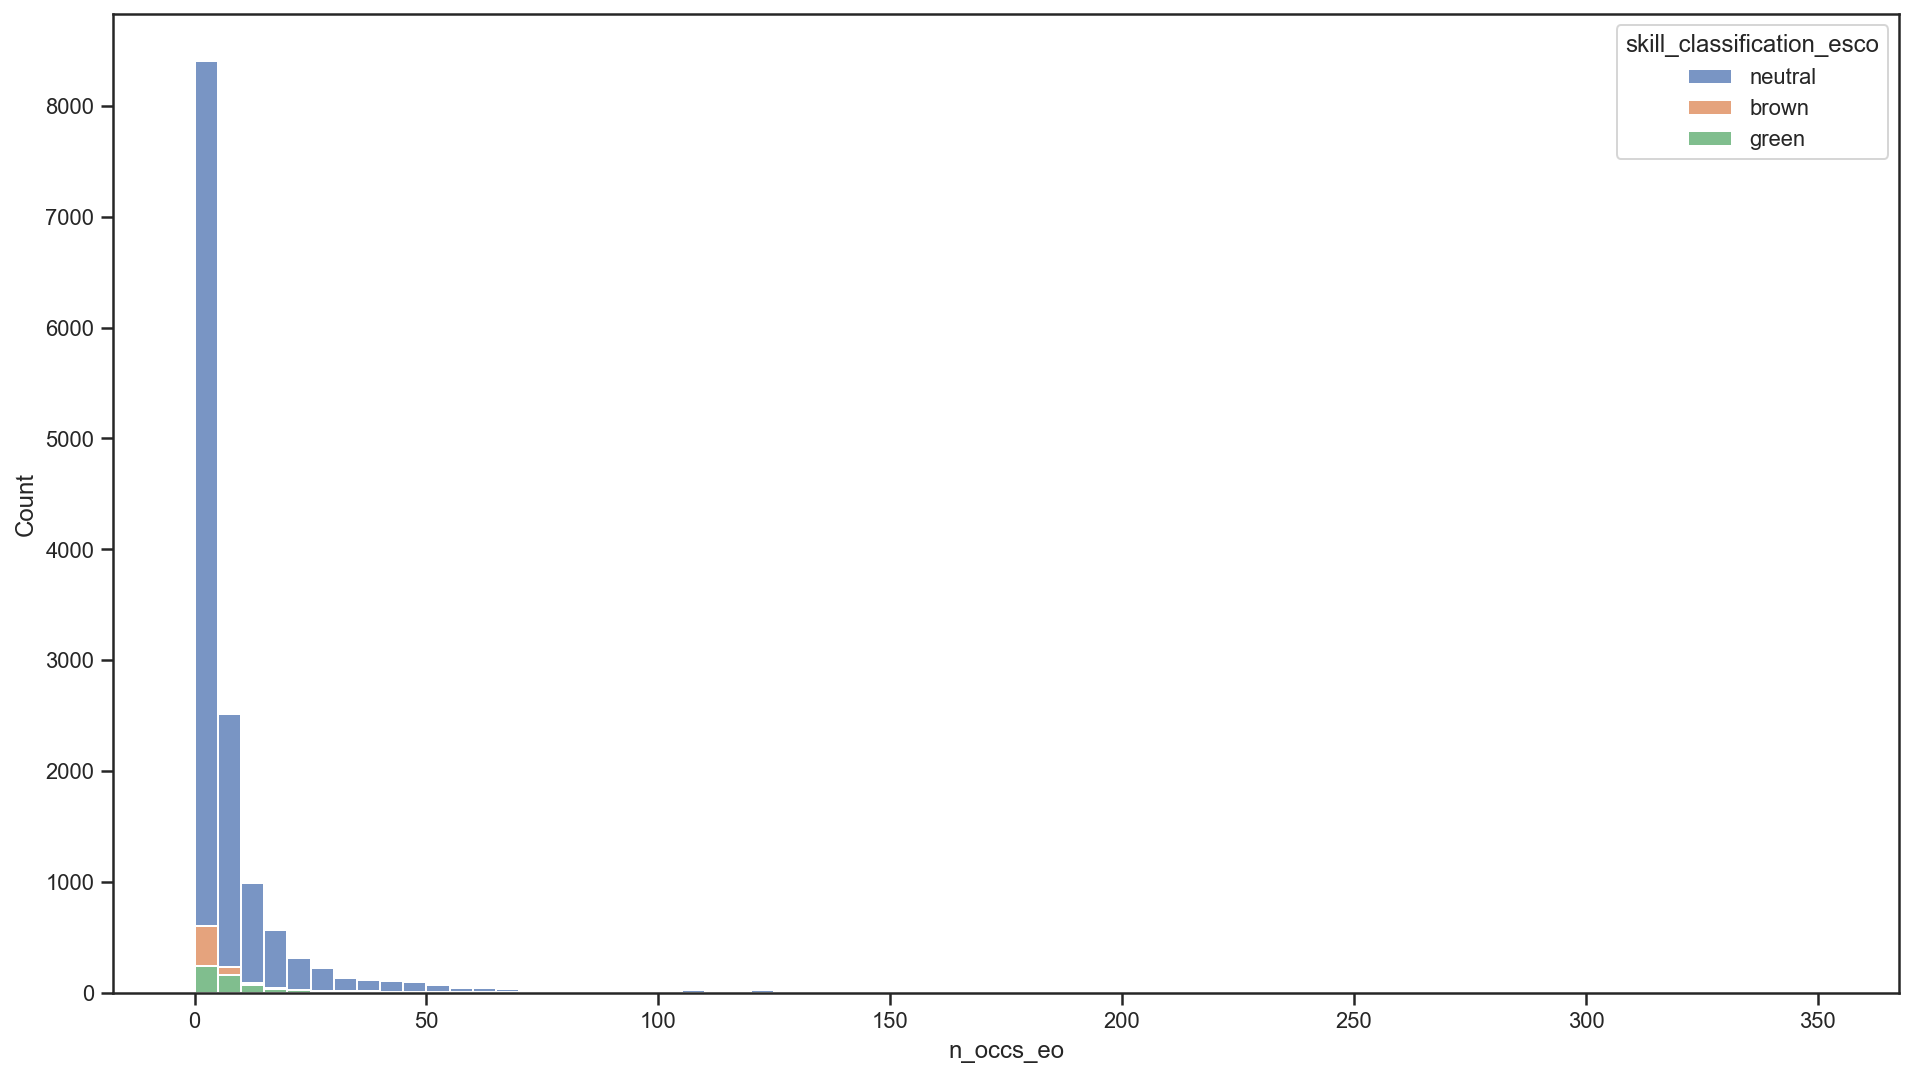

In [11]:
sns.histplot(
    data=of.skills_metadata,
    x="n_occs_eo",
    hue="skill_classification_esco",
    stat="count",
    multiple="stack",
    # log_scale=[False, True],
    binwidth=5,
    hue_order=["neutral", "brown", "green"],
)

<AxesSubplot:xlabel='n_occs_e', ylabel='Count'>

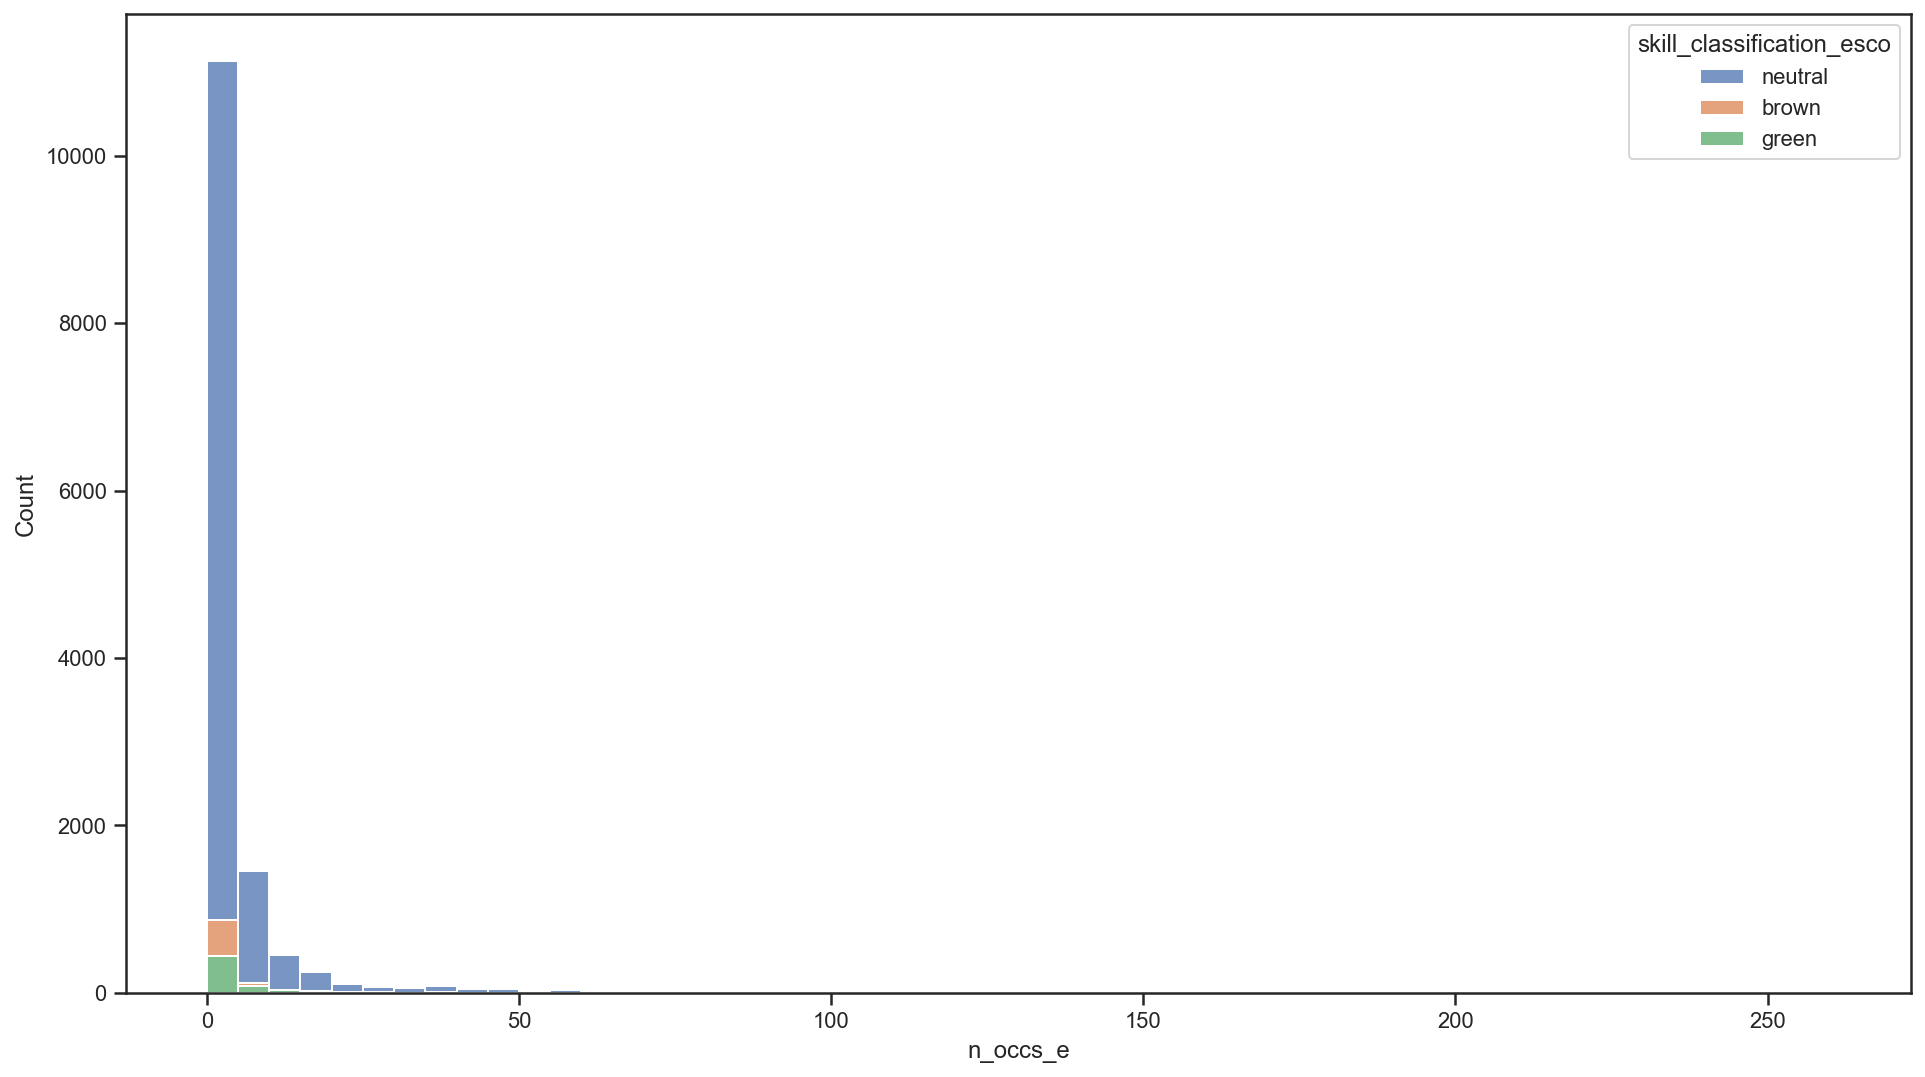

In [12]:
sns.histplot(
    data=of.skills_metadata,
    x="n_occs_e",
    hue="skill_classification_esco",
    stat="count",
    multiple="stack",
    # log_scale=[False, True],
    binwidth=5,
    hue_order=["neutral", "brown", "green"],
)